# 06 - Análisis de promociones y descuentos

Este notebook tiene como objetivo analizar el comportamiento de las promociones y descuentos dentro de la base de ventas.

El análisis busca responder preguntas como:

- ¿Qué porcentaje de líneas tiene promoción o descuento?
- ¿Cuánto representa la venta promocional frente a la venta total?
- ¿Qué PDV tiene mayor participación de promociones?
- ¿Qué categorías concentran más descuentos?
- ¿Qué productos dependen más de promociones?
- ¿Las promociones se asocian con mayores unidades vendidas?
- ¿Existen descuentos mayores que la venta?
- ¿Existen ventas netas negativas por efecto del descuento?
- ¿Cómo se comportan las promociones en el tiempo?

La variable principal del análisis será `VENTA_NETA`, calculada como:

`VENTA_NETA = VENTA - DESCUENTO`

También se analizarán variables como:

- `PROMO_FLAG`
- `TIPO_PROMO`
- `DESCUENTO`
- `DESCUENTO_PCT`
- `OFERTA_ID`

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

PROMOCIONES_FIGURES_DIR = FIGURES_DIR / "promociones"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"

PROMOCIONES_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo procesado:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo procesado:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de base limpia
# ===============================

df = pd.read_parquet(PROCESSED_FILE)

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base procesada cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base procesada cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [6]:
# ===============================
# Validación de columnas necesarias
# ===============================

columnas_necesarias = [
    "FECHA",
    "ANIO",
    "MES",
    "PDV",
    "Estrato",
    "CATEG",
    "GRUCOM",
    "PLU_SAP",
    "TICKET_ID",
    "OFERTA_ID",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PROMO_FLAG",
    "PROMO_OFERTA_FLAG",
    "PROMO_DESCUENTO_FLAG",
    "TIPO_PROMO",
    "REGISTRO_ESPECIAL",
    "REGISTRO_VALIDO_BASICO"
]

faltantes = [col for col in columnas_necesarias if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas necesarias están disponibles.")
else:
    print("Faltan estas columnas:")
    print(faltantes)

Todas las columnas necesarias están disponibles.


In [7]:
# ===============================
# Resumen general de promociones
# ===============================

total_filas = len(df)
total_venta_bruta = df["VENTA"].sum()
total_descuento = df["DESCUENTO"].sum()
total_venta_neta = df["VENTA_NETA"].sum()
total_unidades = df["CANT"].sum()
total_tickets = df["TICKET_ID"].nunique()

filas_promo = df["PROMO_FLAG"].sum()
filas_sin_promo = total_filas - filas_promo

venta_neta_promo = df.loc[df["PROMO_FLAG"], "VENTA_NETA"].sum()
venta_neta_sin_promo = df.loc[~df["PROMO_FLAG"], "VENTA_NETA"].sum()

resumen_promociones_general = pd.DataFrame({
    "metrica": [
        "Filas totales",
        "Filas con promoción",
        "Filas sin promoción",
        "% filas con promoción",
        "Venta bruta total",
        "Descuento total",
        "Venta neta total",
        "Venta neta promocional",
        "Venta neta no promocional",
        "% venta neta promocional",
        "Unidades totales",
        "Tickets únicos",
        "Descuento / venta bruta (%)"
    ],
    "valor": [
        total_filas,
        filas_promo,
        filas_sin_promo,
        filas_promo / total_filas * 100,
        total_venta_bruta,
        total_descuento,
        total_venta_neta,
        venta_neta_promo,
        venta_neta_sin_promo,
        venta_neta_promo / total_venta_neta * 100 if total_venta_neta != 0 else np.nan,
        total_unidades,
        total_tickets,
        total_descuento / total_venta_bruta * 100 if total_venta_bruta != 0 else np.nan
    ]
})

resumen_promociones_general

,metrica,valor
0,Filas totales,"409,760.00"
1,Filas con promoción,"109,239.00"
2,Filas sin promoción,"300,521.00"
3,% filas con promoción,26.66
4,Venta bruta total,"139,462,498.00"
5,Descuento total,"16,270,136.00"
6,Venta neta total,"123,192,362.00"
7,Venta neta promocional,"25,002,304.00"
8,Venta neta no promocional,"98,190,058.00"
9,% venta neta promocional,20.30


In [8]:
# ===============================
# Comparación promoción vs no promoción
# ===============================

resumen_promo_flag = (
    df.groupby("PROMO_FLAG")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        categorias=("CATEG", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

resumen_promo_flag["tipo_linea"] = resumen_promo_flag["PROMO_FLAG"].map({
    False: "Sin promoción",
    True: "Con promoción"
})

resumen_promo_flag["participacion_filas_pct"] = (
    resumen_promo_flag["filas"] / resumen_promo_flag["filas"].sum() * 100
)

resumen_promo_flag["participacion_venta_neta_pct"] = (
    resumen_promo_flag["venta_neta"] / resumen_promo_flag["venta_neta"].sum() * 100
)

resumen_promo_flag["ticket_promedio_neto"] = np.where(
    resumen_promo_flag["tickets"] > 0,
    resumen_promo_flag["venta_neta"] / resumen_promo_flag["tickets"],
    np.nan
)

resumen_promo_flag["unidades_por_ticket"] = np.where(
    resumen_promo_flag["tickets"] > 0,
    resumen_promo_flag["unidades"] / resumen_promo_flag["tickets"],
    np.nan
)

resumen_promo_flag["descuento_pct"] = np.where(
    resumen_promo_flag["venta_bruta"] > 0,
    resumen_promo_flag["descuento"] / resumen_promo_flag["venta_bruta"] * 100,
    np.nan
)

resumen_promo_flag

,PROMO_FLAG,filas,dias,tickets,productos,categorias,venta_bruta,descuento,venta_neta,unidades,registros_especiales,tipo_linea,participacion_filas_pct,participacion_venta_neta_pct,ticket_promedio_neto,unidades_por_ticket,descuento_pct
0,False,300521,731,231577,5684,7,"98,190,058.00",0.00,"98,190,058.00","366,423.92",2505,Sin promoción,73.34,79.70,424.01,1.58,0.00
1,True,109239,731,70215,4822,6,"41,272,440.00","16,270,136.00","25,002,304.00","128,549.31",10992,Con promoción,26.66,20.30,356.08,1.83,39.42


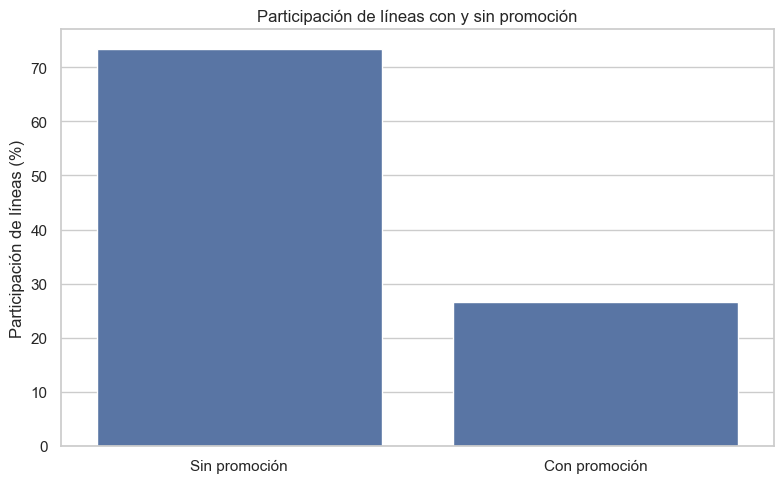

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\participacion_lineas_promo.png


In [9]:
# ===============================
# Participación de líneas con promoción
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_promo_flag,
    x="tipo_linea",
    y="participacion_filas_pct"
)

plt.title("Participación de líneas con y sin promoción")
plt.xlabel("")
plt.ylabel("Participación de líneas (%)")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "participacion_lineas_promo.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

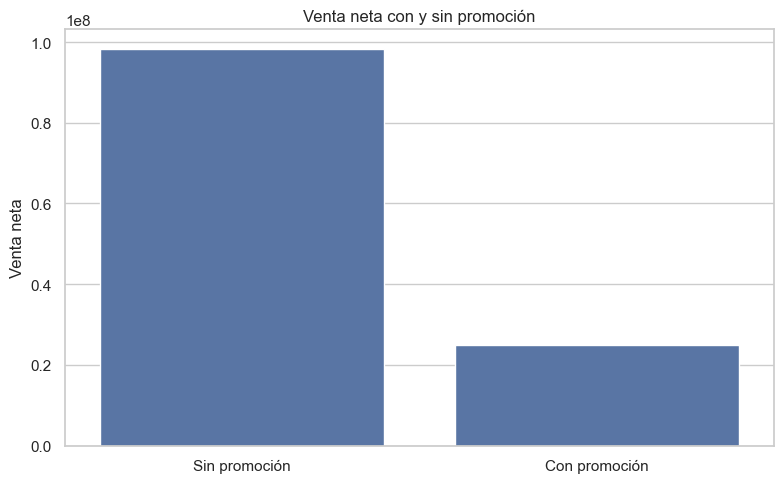

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\venta_neta_con_sin_promocion.png


In [10]:
# ===============================
# Venta neta con y sin promoción
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_promo_flag,
    x="tipo_linea",
    y="venta_neta"
)

plt.title("Venta neta con y sin promoción")
plt.xlabel("")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "venta_neta_con_sin_promocion.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [11]:
# ===============================
# Resumen por tipo de promoción
# ===============================

resumen_tipo_promo = (
    df.groupby("TIPO_PROMO")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        categorias=("CATEG", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum")
    )
    .reset_index()
)

resumen_tipo_promo["participacion_filas_pct"] = (
    resumen_tipo_promo["filas"] / resumen_tipo_promo["filas"].sum() * 100
)

resumen_tipo_promo["participacion_venta_neta_pct"] = (
    resumen_tipo_promo["venta_neta"] / resumen_tipo_promo["venta_neta"].sum() * 100
)

resumen_tipo_promo["descuento_pct"] = np.where(
    resumen_tipo_promo["venta_bruta"] > 0,
    resumen_tipo_promo["descuento"] / resumen_tipo_promo["venta_bruta"] * 100,
    np.nan
)

resumen_tipo_promo["ticket_promedio_neto"] = np.where(
    resumen_tipo_promo["tickets"] > 0,
    resumen_tipo_promo["venta_neta"] / resumen_tipo_promo["tickets"],
    np.nan
)

resumen_tipo_promo = resumen_tipo_promo.sort_values("venta_neta", ascending=False)

resumen_tipo_promo

,TIPO_PROMO,filas,dias,tickets,productos,categorias,venta_bruta,descuento,venta_neta,unidades,registros_especiales,participacion_filas_pct,participacion_venta_neta_pct,descuento_pct,ticket_promedio_neto
1,Sin promoción,300521,731,231577,5684,7,"98,190,058.00",0.00,"98,190,058.00","366,423.92",2505,73.34,79.70,0.00,424.01
0,Oferta y descuento,108902,731,70062,4821,6,"41,252,478.00","16,261,154.00","24,991,324.00","128,312.62",10953,26.58,20.29,39.42,356.70
2,Solo descuento,91,78,83,74,5,"26,814.00","10,920.00","15,894.00",82.78,25,0.02,0.01,40.72,191.49
3,Solo oferta,246,127,226,44,5,"-6,852.00","-1,938.00","-4,914.00",153.91,14,0.06,-0.00,NaN,-21.74


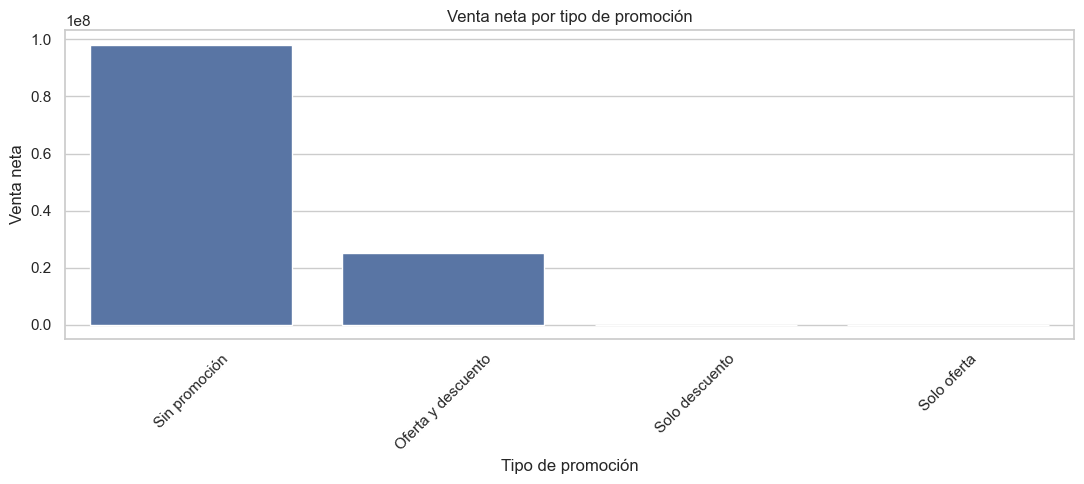

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\venta_neta_tipo_promocion.png


In [12]:
# ===============================
# Venta neta por tipo de promoción
# ===============================

plt.figure(figsize=(11, 5))

sns.barplot(
    data=resumen_tipo_promo,
    x="TIPO_PROMO",
    y="venta_neta"
)

plt.title("Venta neta por tipo de promoción")
plt.xlabel("Tipo de promoción")
plt.ylabel("Venta neta")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "venta_neta_tipo_promocion.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

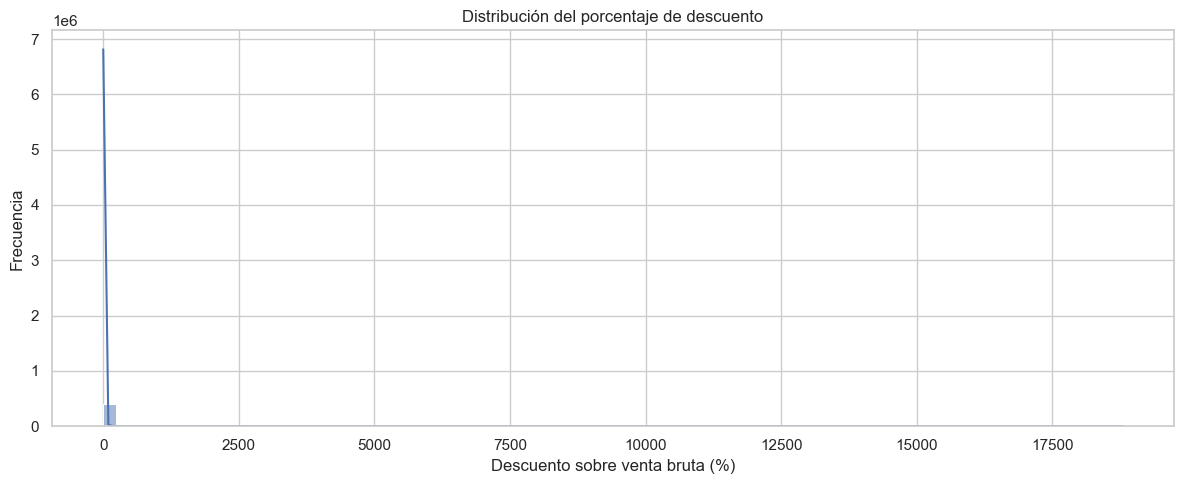

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\distribucion_descuento_pct.png


In [13]:
# ===============================
# Distribución del porcentaje de descuento
# ===============================

df_descuento_valido = df[
    df["DESCUENTO_PCT"].notna() &
    np.isfinite(df["DESCUENTO_PCT"])
].copy()

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_descuento_valido,
    x="DESCUENTO_PCT",
    bins=80,
    kde=True
)

plt.title("Distribución del porcentaje de descuento")
plt.xlabel("Descuento sobre venta bruta (%)")
plt.ylabel("Frecuencia")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "distribucion_descuento_pct.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [14]:
# ===============================
# Estadísticos de descuento
# ===============================

estadisticos_descuento = df[[
    "DESCUENTO",
    "DESCUENTO_PCT",
    "VENTA",
    "VENTA_NETA"
]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

estadisticos_descuento

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
DESCUENTO,"409,760.00",39.71,269.24,-862.00,0.00,0.00,0.00,0.00,0.00,8.00,113.00,228.00,574.00,"80,080.00"
DESCUENTO_PCT,"404,527.00",11.72,54.71,0.00,0.00,0.00,0.00,0.00,0.00,10.00,25.00,53.75,150.00,"18,800.00"
VENTA,"409,760.00",340.35,807.68,"-32,896.00",0.00,21.00,36.00,83.00,178.00,398.00,758.00,"1,116.00","2,289.00","195,457.00"
VENTA_NETA,"409,760.00",300.65,754.94,"-43,460.00",-168.00,11.00,30.00,75.00,164.00,342.00,697.00,"1,018.00","2,137.41","195,457.00"


In [15]:
# ===============================
# Promociones por PDV
# ===============================

promo_pdv = (
    df.groupby(["PDV", "Estrato"])
    .agg(
        filas=("NroReg", "count"),
        lineas_promo=("PROMO_FLAG", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum")
    )
    .reset_index()
)

promo_pdv["promo_pct_lineas"] = np.where(
    promo_pdv["filas"] > 0,
    promo_pdv["lineas_promo"] / promo_pdv["filas"] * 100,
    np.nan
)

promo_pdv["descuento_pct"] = np.where(
    promo_pdv["venta_bruta"] > 0,
    promo_pdv["descuento"] / promo_pdv["venta_bruta"] * 100,
    np.nan
)

promo_pdv["participacion_descuento_pct"] = (
    promo_pdv["descuento"] / promo_pdv["descuento"].sum() * 100
)

promo_pdv["participacion_venta_neta_pct"] = (
    promo_pdv["venta_neta"] / promo_pdv["venta_neta"].sum() * 100
)

promo_pdv = promo_pdv.sort_values("venta_neta", ascending=False)

promo_pdv

,PDV,Estrato,filas,lineas_promo,tickets,productos,venta_bruta,descuento,venta_neta,unidades,promo_pct_lineas,descuento_pct,participacion_descuento_pct,participacion_venta_neta_pct
1,1311,6,201432,57887,129256,5142,"80,638,414.00","8,777,219.00","71,861,195.00","232,738.60",28.74,10.88,53.95,58.33
0,1255,4,132627,33129,93693,3736,"38,023,322.00","5,281,154.00","32,742,168.00","165,580.55",24.98,13.89,32.46,26.58
2,980,4,75701,18223,54040,2461,"20,800,762.00","2,211,763.00","18,588,999.00","96,654.08",24.07,10.63,13.59,15.09


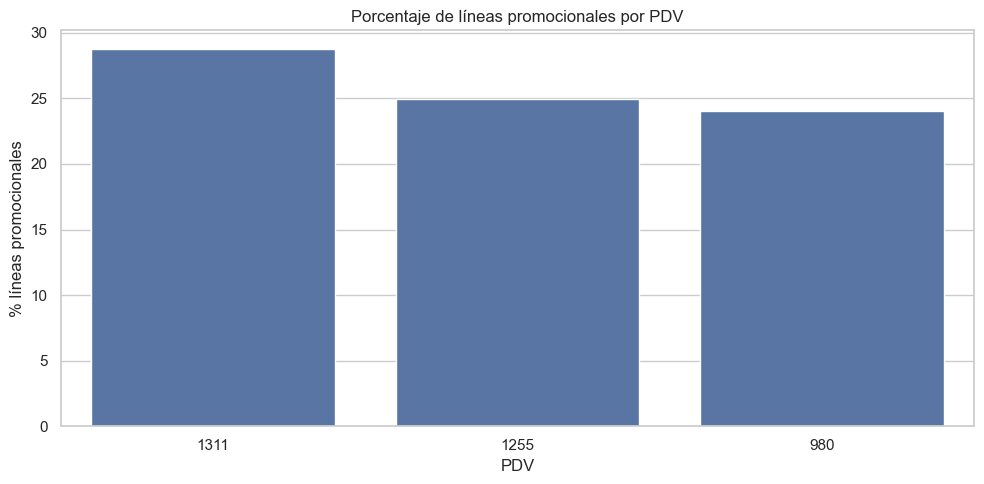

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\promo_pct_lineas_por_pdv.png


In [16]:
# ===============================
# Porcentaje de líneas promocionales por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=promo_pdv,
    x="PDV",
    y="promo_pct_lineas"
)

plt.title("Porcentaje de líneas promocionales por PDV")
plt.xlabel("PDV")
plt.ylabel("% líneas promocionales")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "promo_pct_lineas_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

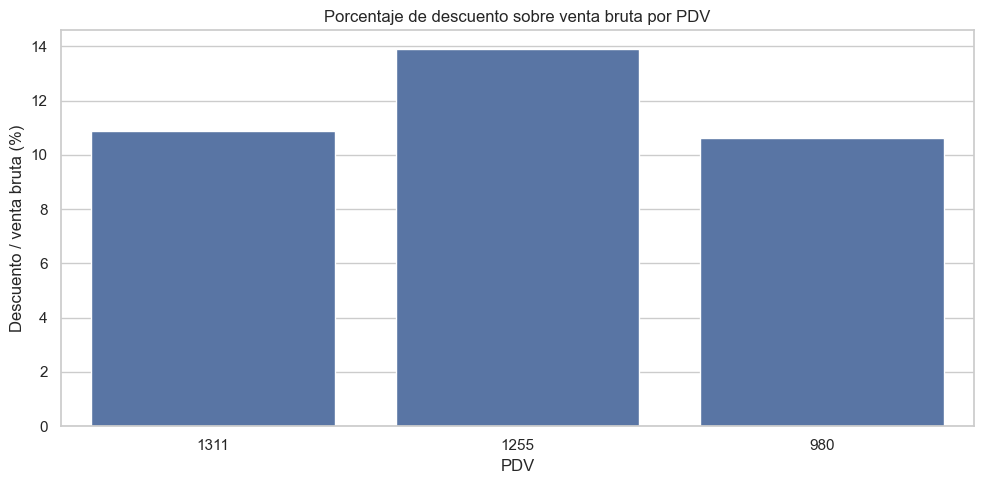

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\descuento_pct_por_pdv.png


In [17]:
# ===============================
# Porcentaje de descuento por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=promo_pdv,
    x="PDV",
    y="descuento_pct"
)

plt.title("Porcentaje de descuento sobre venta bruta por PDV")
plt.xlabel("PDV")
plt.ylabel("Descuento / venta bruta (%)")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "descuento_pct_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [18]:
# ===============================
# Promociones por categoría
# ===============================

promo_categoria = (
    df.groupby(["GRUCOM", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        lineas_promo=("PROMO_FLAG", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum")
    )
    .reset_index()
)

promo_categoria["promo_pct_lineas"] = np.where(
    promo_categoria["filas"] > 0,
    promo_categoria["lineas_promo"] / promo_categoria["filas"] * 100,
    np.nan
)

promo_categoria["descuento_pct"] = np.where(
    promo_categoria["venta_bruta"] > 0,
    promo_categoria["descuento"] / promo_categoria["venta_bruta"] * 100,
    np.nan
)

promo_categoria["participacion_descuento_pct"] = (
    promo_categoria["descuento"] / promo_categoria["descuento"].sum() * 100
)

promo_categoria["participacion_venta_neta_pct"] = (
    promo_categoria["venta_neta"] / promo_categoria["venta_neta"].sum() * 100
)

promo_categoria = promo_categoria.sort_values("venta_neta", ascending=False)

promo_categoria

,GRUCOM,CATEG,filas,lineas_promo,tickets,productos,venta_bruta,descuento,venta_neta,unidades,promo_pct_lineas,descuento_pct,participacion_descuento_pct,participacion_venta_neta_pct
0,10,04010,158659,32262,121604,1173,"61,096,386.00","7,317,028.00","53,779,358.00","244,163.00",20.33,11.98,44.97,43.65
3,11,08042,52788,16647,41127,1748,"29,985,976.00","2,868,994.00","27,116,982.00","60,593.26",31.54,9.57,17.63,22.01
2,11,08029,132505,40592,95594,1391,"29,011,472.00","3,044,652.00","25,966,820.00","123,061.92",30.63,10.49,18.71,21.08
4,11,08061,53538,13414,42098,804,"10,970,778.00","816,908.00","10,153,870.00","54,349.08",25.06,7.45,5.02,8.24
5,11,08062,10997,6321,8608,666,"7,667,928.00","2,222,411.00","5,445,517.00","10,972.18",57.48,28.98,13.66,4.42
6,11,08067,876,3,355,255,"698,356.00",143.00,"698,213.00","1,373.79",0.34,0.02,0.00,0.57
1,10,04019,397,0,392,2,"31,602.00",0.00,"31,602.00",460.00,0.00,0.00,0.00,0.03


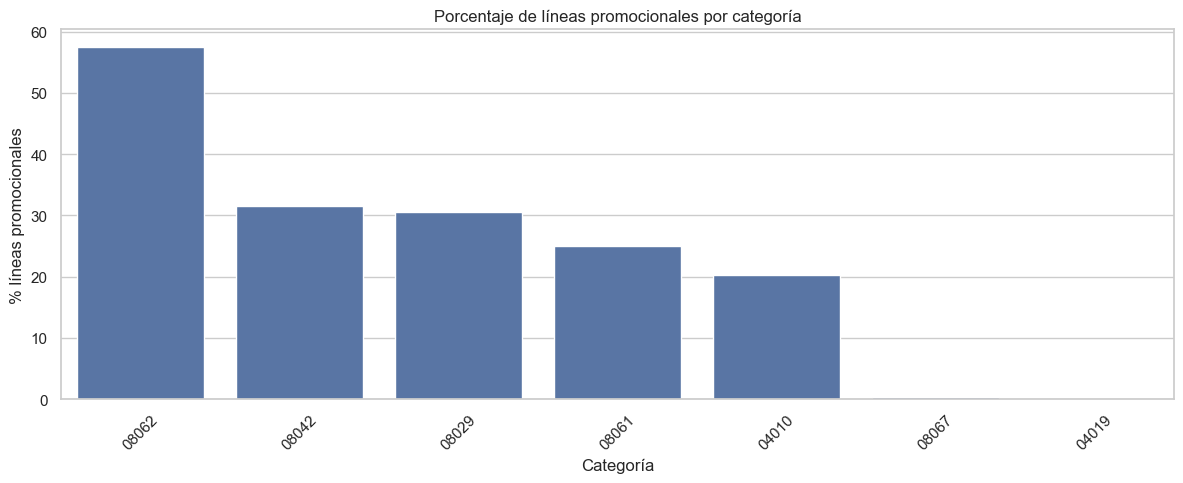

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\promo_pct_lineas_por_categoria.png


In [19]:
# ===============================
# Porcentaje de líneas promocionales por categoría
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=promo_categoria.sort_values("promo_pct_lineas", ascending=False),
    x="CATEG",
    y="promo_pct_lineas"
)

plt.title("Porcentaje de líneas promocionales por categoría")
plt.xlabel("Categoría")
plt.ylabel("% líneas promocionales")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "promo_pct_lineas_por_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

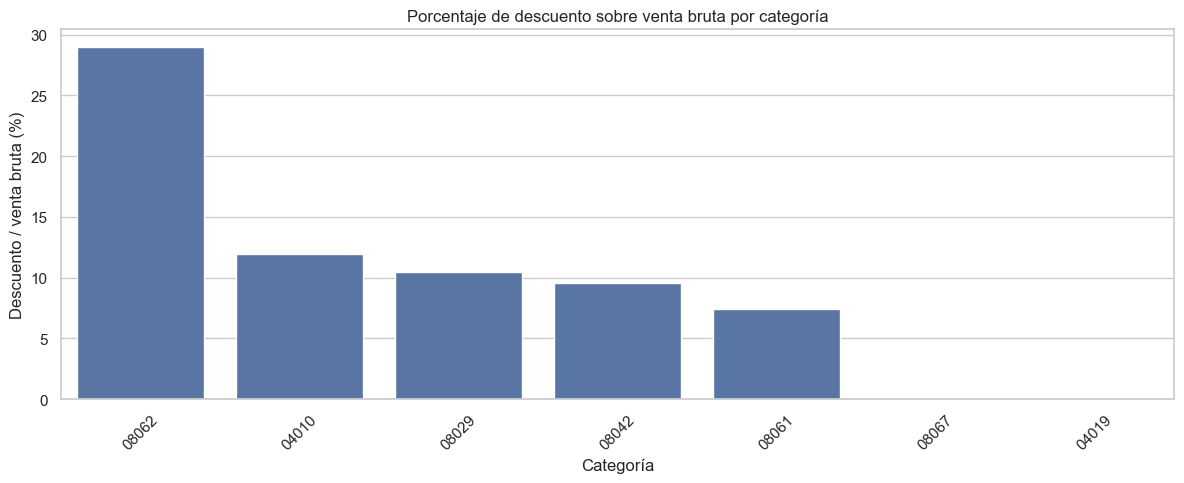

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\descuento_pct_por_categoria.png


In [20]:
# ===============================
# Porcentaje de descuento por categoría
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=promo_categoria.sort_values("descuento_pct", ascending=False),
    x="CATEG",
    y="descuento_pct"
)

plt.title("Porcentaje de descuento sobre venta bruta por categoría")
plt.xlabel("Categoría")
plt.ylabel("Descuento / venta bruta (%)")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "descuento_pct_por_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [21]:
# ===============================
# Promociones por día
# ===============================

promo_diaria = (
    df.groupby("FECHA")
    .agg(
        filas=("NroReg", "count"),
        lineas_promo=("PROMO_FLAG", "sum"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
)

promo_diaria["promo_pct_lineas"] = np.where(
    promo_diaria["filas"] > 0,
    promo_diaria["lineas_promo"] / promo_diaria["filas"] * 100,
    np.nan
)

promo_diaria["descuento_pct"] = np.where(
    promo_diaria["venta_bruta"] > 0,
    promo_diaria["descuento"] / promo_diaria["venta_bruta"] * 100,
    np.nan
)

promo_diaria["venta_neta_rolling_7d"] = promo_diaria["venta_neta"].rolling(7, min_periods=1).mean()
promo_diaria["promo_pct_rolling_7d"] = promo_diaria["promo_pct_lineas"].rolling(7, min_periods=1).mean()
promo_diaria["descuento_pct_rolling_7d"] = promo_diaria["descuento_pct"].rolling(7, min_periods=1).mean()

promo_diaria.head()

,FECHA,filas,lineas_promo,venta_bruta,descuento,venta_neta,unidades,tickets,promo_pct_lineas,descuento_pct,venta_neta_rolling_7d,promo_pct_rolling_7d,descuento_pct_rolling_7d
0,2023-01-01,267,19,"69,600.00","1,449.00","68,151.00",362.73,195,7.12,2.08,"68,151.00",7.12,2.08
1,2023-01-02,452,27,"134,835.00","1,457.00","133,378.00",598.25,317,5.97,1.08,"100,764.50",6.54,1.58
2,2023-01-03,425,18,"111,415.00",329.00,"111,086.00",548.14,303,4.24,0.30,"104,205.00",5.77,1.15
3,2023-01-04,542,25,"145,023.00",838.00,"144,185.00",646.77,400,4.61,0.58,"114,200.00",5.48,1.01
4,2023-01-05,478,29,"141,029.00","1,060.00","139,969.00",762.87,371,6.07,0.75,"119,353.80",5.60,0.96


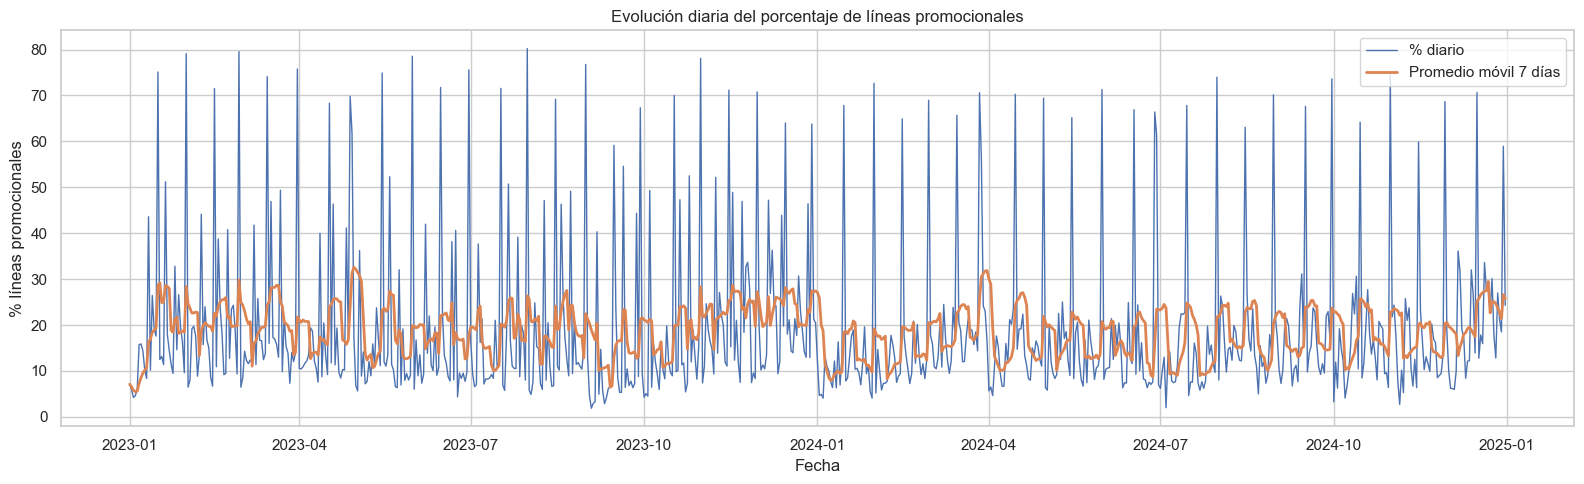

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\evolucion_diaria_promo_pct.png


In [22]:
# ===============================
# Porcentaje diario de líneas promocionales
# ===============================

plt.figure(figsize=(16, 5))

sns.lineplot(
    data=promo_diaria,
    x="FECHA",
    y="promo_pct_lineas",
    linewidth=1,
    label="% diario"
)

sns.lineplot(
    data=promo_diaria,
    x="FECHA",
    y="promo_pct_rolling_7d",
    linewidth=2,
    label="Promedio móvil 7 días"
)

plt.title("Evolución diaria del porcentaje de líneas promocionales")
plt.xlabel("Fecha")
plt.ylabel("% líneas promocionales")
plt.legend()
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "evolucion_diaria_promo_pct.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

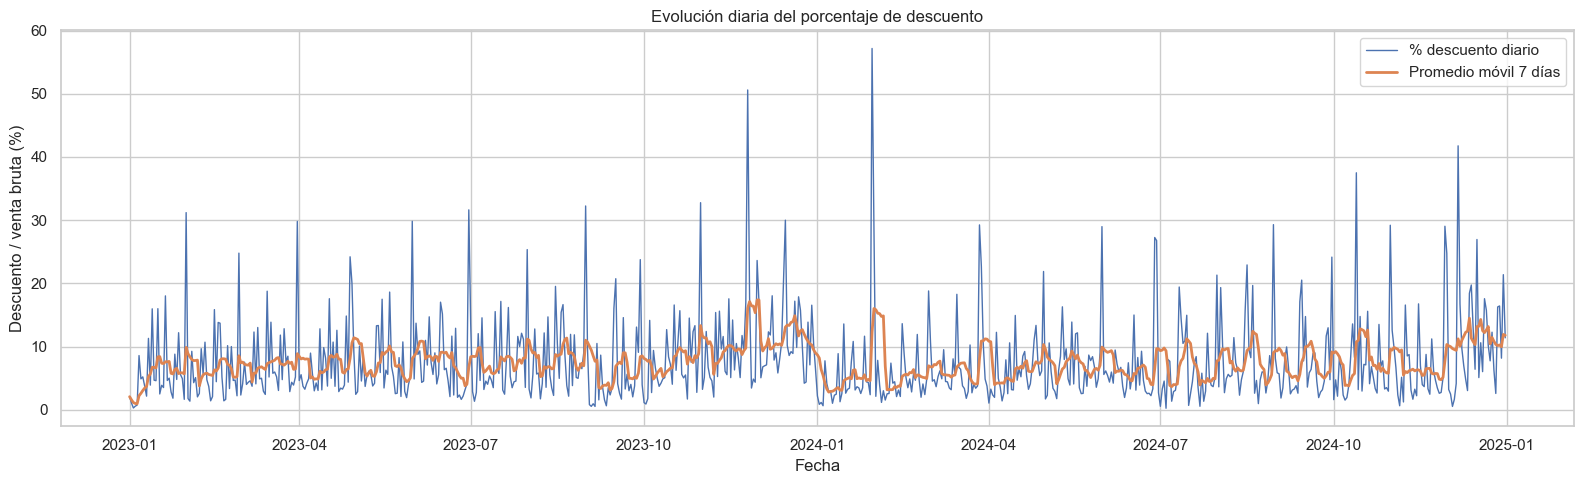

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\evolucion_diaria_descuento_pct.png


In [23]:
# ===============================
# Evolución diaria del porcentaje de descuento
# ===============================

plt.figure(figsize=(16, 5))

sns.lineplot(
    data=promo_diaria,
    x="FECHA",
    y="descuento_pct",
    linewidth=1,
    label="% descuento diario"
)

sns.lineplot(
    data=promo_diaria,
    x="FECHA",
    y="descuento_pct_rolling_7d",
    linewidth=2,
    label="Promedio móvil 7 días"
)

plt.title("Evolución diaria del porcentaje de descuento")
plt.xlabel("Fecha")
plt.ylabel("Descuento / venta bruta (%)")
plt.legend()
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "evolucion_diaria_descuento_pct.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

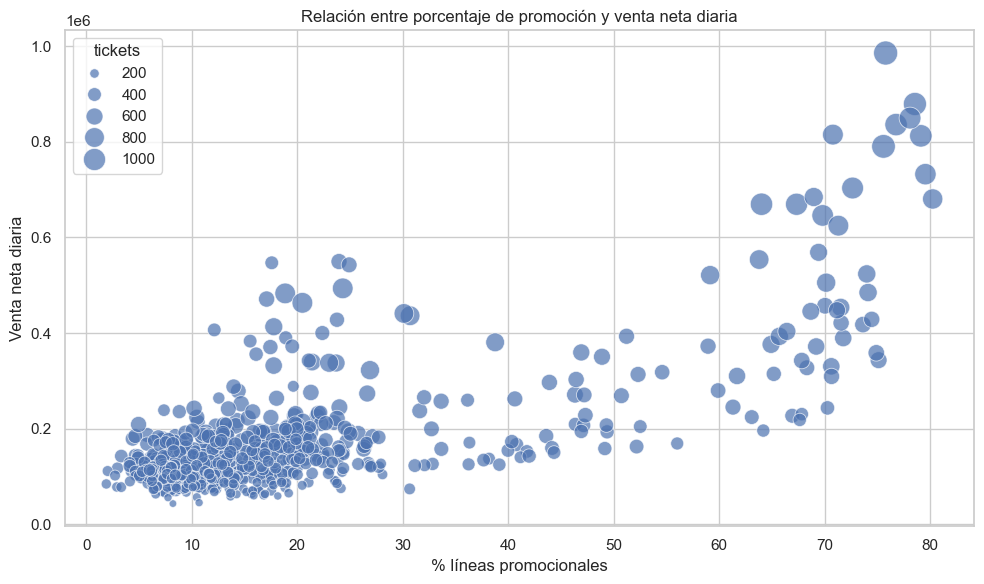

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\promo_pct_vs_venta_neta_diaria.png


In [24]:
# ===============================
# Relación entre promoción y venta neta diaria
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=promo_diaria,
    x="promo_pct_lineas",
    y="venta_neta",
    size="tickets",
    sizes=(30, 300),
    alpha=0.7
)

plt.title("Relación entre porcentaje de promoción y venta neta diaria")
plt.xlabel("% líneas promocionales")
plt.ylabel("Venta neta diaria")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "promo_pct_vs_venta_neta_diaria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

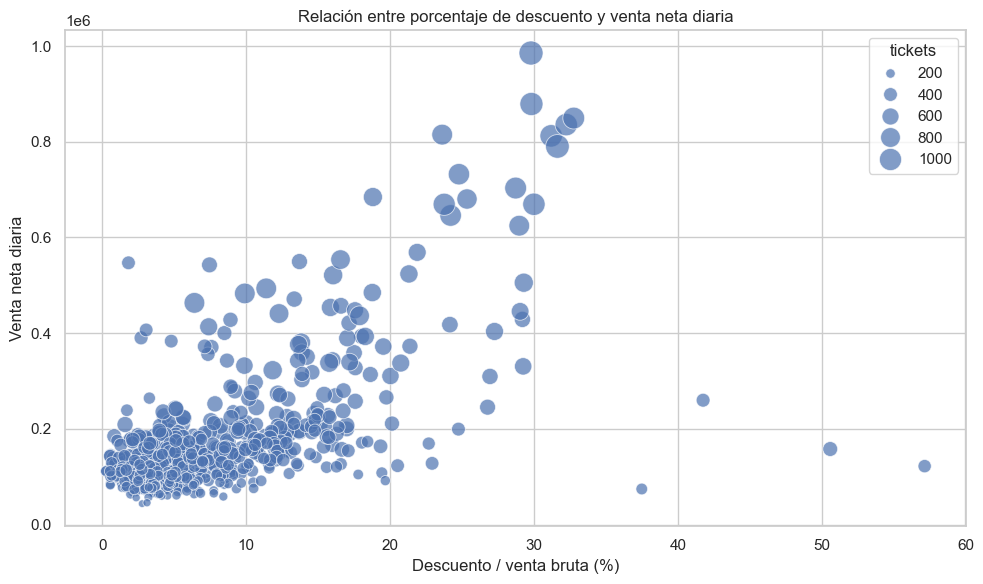

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\descuento_pct_vs_venta_neta_diaria.png


In [25]:
# ===============================
# Relación entre descuento y venta neta diaria
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=promo_diaria,
    x="descuento_pct",
    y="venta_neta",
    size="tickets",
    sizes=(30, 300),
    alpha=0.7
)

plt.title("Relación entre porcentaje de descuento y venta neta diaria")
plt.xlabel("Descuento / venta bruta (%)")
plt.ylabel("Venta neta diaria")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "descuento_pct_vs_venta_neta_diaria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [26]:
# ===============================
# Promociones por mes
# ===============================

promo_mensual = (
    df.groupby(["ANIO", "MES", "MES_NOMBRE"])
    .agg(
        filas=("NroReg", "count"),
        lineas_promo=("PROMO_FLAG", "sum"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
)

promo_mensual["FECHA_MES"] = pd.to_datetime(
    promo_mensual["ANIO"].astype(str) + "-" +
    promo_mensual["MES"].astype(str) + "-01"
)

promo_mensual["promo_pct_lineas"] = np.where(
    promo_mensual["filas"] > 0,
    promo_mensual["lineas_promo"] / promo_mensual["filas"] * 100,
    np.nan
)

promo_mensual["descuento_pct"] = np.where(
    promo_mensual["venta_bruta"] > 0,
    promo_mensual["descuento"] / promo_mensual["venta_bruta"] * 100,
    np.nan
)

promo_mensual = promo_mensual.sort_values("FECHA_MES")

promo_mensual

,ANIO,MES,MES_NOMBRE,filas,lineas_promo,venta_bruta,descuento,venta_neta,unidades,tickets,FECHA_MES,promo_pct_lineas,descuento_pct
0,2023,1,Enero,19219,5776,"6,211,723.00","745,966.00","5,465,757.00","22,597.54",12669,2023-01-01,30.05,12.01
1,2023,2,Febrero,18338,5604,"6,300,692.00","672,380.00","5,628,312.00","22,347.45",12400,2023-02-01,30.56,10.67
2,2023,3,Marzo,19554,6132,"6,691,739.00","859,475.00","5,832,264.00","22,791.83",12841,2023-03-01,31.36,12.84
3,2023,4,Abril,17026,4974,"5,478,481.00","609,793.00","4,868,688.00","19,256.93",11494,2023-04-01,29.21,11.13
4,2023,5,Mayo,18277,5196,"6,399,346.00","814,573.00","5,584,773.00","22,820.27",12397,2023-05-01,28.43,12.73
5,2023,6,Junio,18385,5127,"6,172,996.00","796,728.00","5,376,268.00","22,858.76",12374,2023-06-01,27.89,12.91
6,2023,7,Julio,18324,4968,"5,966,422.00","688,574.00","5,277,848.00","22,227.83",12391,2023-07-01,27.11,11.54
7,2023,8,Agosto,19176,5549,"6,205,561.00","855,600.00","5,349,961.00","22,108.96",12850,2023-08-01,28.94,13.79
8,2023,9,Septiembre,18544,4220,"6,306,122.00","635,949.00","5,670,173.00","22,987.99",13018,2023-09-01,22.76,10.08
9,2023,10,Octubre,17587,5044,"6,407,604.00","877,939.00","5,529,665.00","21,856.50",11815,2023-10-01,28.68,13.70


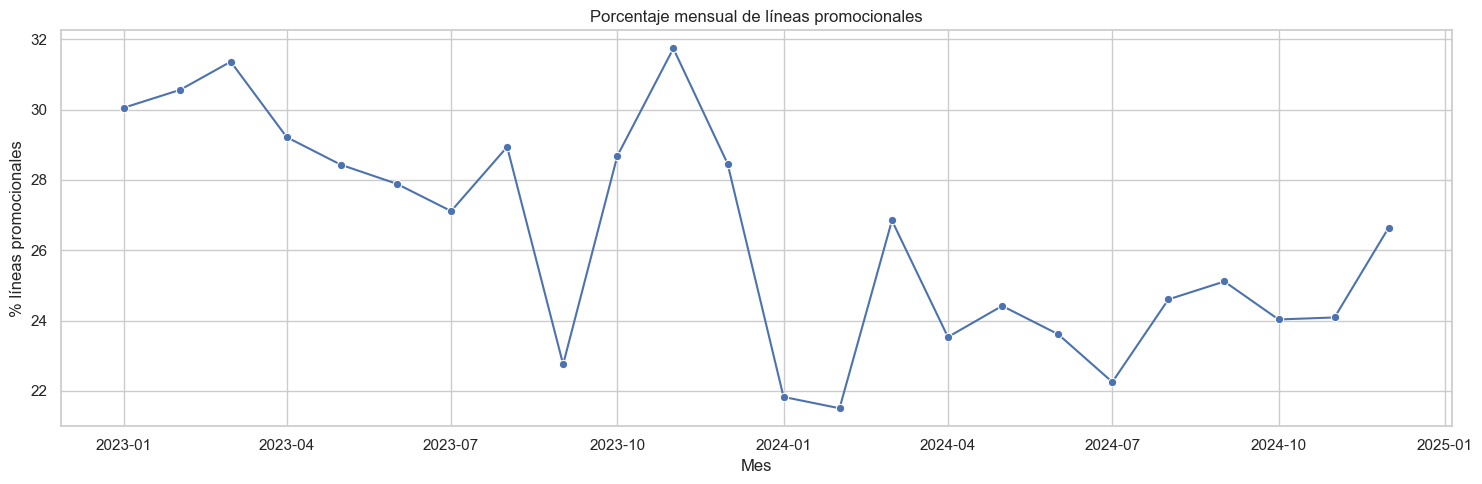

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\promo_pct_mensual.png


In [27]:
# ===============================
# Promoción mensual
# ===============================

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=promo_mensual,
    x="FECHA_MES",
    y="promo_pct_lineas",
    marker="o"
)

plt.title("Porcentaje mensual de líneas promocionales")
plt.xlabel("Mes")
plt.ylabel("% líneas promocionales")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "promo_pct_mensual.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [28]:
# ===============================
# Productos con mayor venta promocional
# ===============================

productos_promo = (
    df.groupby("PLU_SAP")
    .agg(
        filas=("NroReg", "count"),
        lineas_promo=("PROMO_FLAG", "sum"),
        dias=("FECHA", "nunique"),
        pdv=("PDV", "nunique"),
        categoria_principal=("CATEG", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
)

productos_promo["promo_pct_lineas"] = np.where(
    productos_promo["filas"] > 0,
    productos_promo["lineas_promo"] / productos_promo["filas"] * 100,
    np.nan
)

productos_promo["descuento_pct"] = np.where(
    productos_promo["venta_bruta"] > 0,
    productos_promo["descuento"] / productos_promo["venta_bruta"] * 100,
    np.nan
)

productos_promo["venta_neta_promo"] = (
    df[df["PROMO_FLAG"]]
    .groupby("PLU_SAP")["VENTA_NETA"]
    .sum()
    .reindex(productos_promo["PLU_SAP"])
    .fillna(0)
    .values
)

productos_promo["venta_neta_sin_promo"] = (
    df[~df["PROMO_FLAG"]]
    .groupby("PLU_SAP")["VENTA_NETA"]
    .sum()
    .reindex(productos_promo["PLU_SAP"])
    .fillna(0)
    .values
)

productos_promo["participacion_venta_promo_pct"] = np.where(
    productos_promo["venta_neta"] != 0,
    productos_promo["venta_neta_promo"] / productos_promo["venta_neta"] * 100,
    np.nan
)

productos_promo = productos_promo.sort_values("venta_neta_promo", ascending=False)

productos_promo.head(20)

,PLU_SAP,filas,lineas_promo,dias,pdv,categoria_principal,venta_bruta,descuento,venta_neta,unidades,tickets,promo_pct_lineas,descuento_pct,venta_neta_promo,venta_neta_sin_promo,participacion_venta_promo_pct
3166,1246431,842,613,79,3,08029,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",627,72.80,21.23,"503,140.00","759,934.00",39.83
1556,1041245,803,69,410,3,04010,"980,909.00","85,998.00","894,911.00","2,724.00",793,8.59,8.77,"325,529.00","569,382.00",36.38
1516,1036253,2824,601,633,3,04010,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",2682,21.28,27.46,"278,219.00","929,797.00",23.03
1557,1041246,1713,66,624,3,04010,"813,380.00","66,884.00","746,496.00","3,995.00",1704,3.85,8.22,"262,861.00","483,635.00",35.21
1518,1036266,4699,901,697,3,04010,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",4397,19.17,15.84,"234,479.00","1,393,399.00",14.40
1324,1023807,663,243,345,3,04010,"1,113,652.00","118,599.00","995,053.00",771.00,615,36.65,10.65,"212,835.00","782,218.00",21.39
3667,1281459,362,253,37,3,08029,"675,672.00","148,945.00","526,727.00",698.00,257,69.89,22.04,"208,966.00","317,761.00",39.67
2692,1203136,1383,716,589,3,08029,"550,645.00","78,734.00","471,911.00",815.50,1314,51.77,14.30,"204,164.00","267,747.00",43.26
3765,1287168,396,141,210,3,08042,"792,872.00","63,555.00","729,317.00",511.00,373,35.61,8.02,"186,396.00","542,921.00",25.56
2658,1200431,321,256,90,3,08029,"355,659.00","73,592.00","282,067.00",343.00,279,79.75,20.69,"183,342.00","98,725.00",65.00


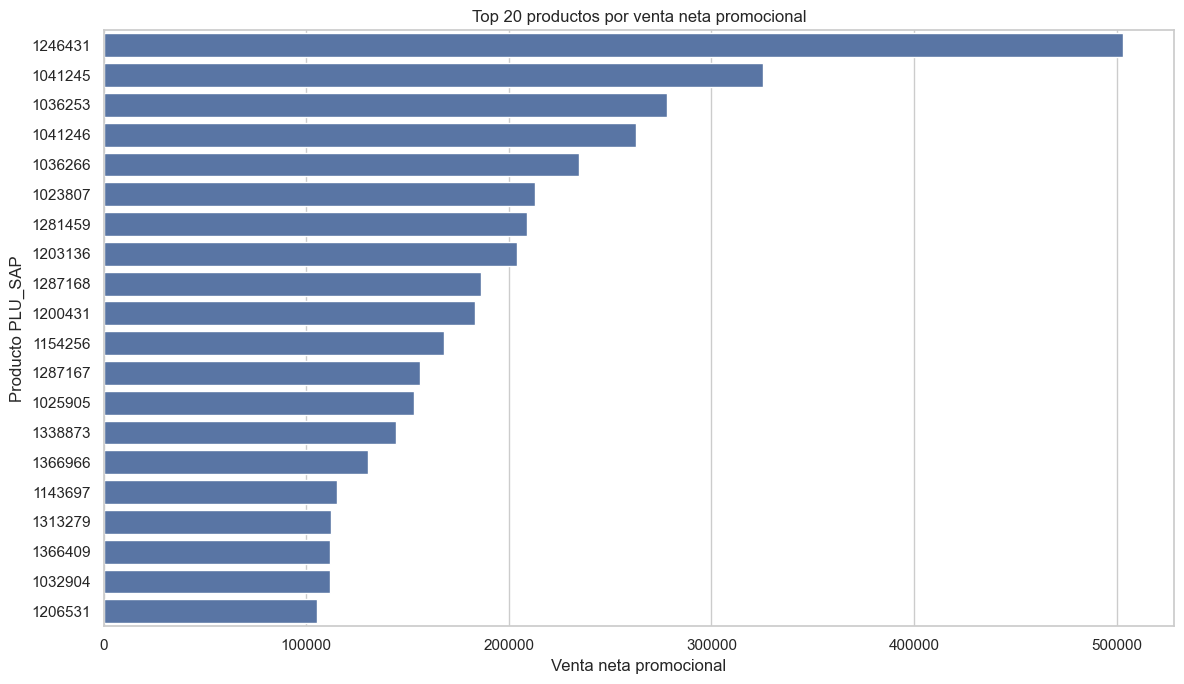

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\top_20_productos_venta_promo.png


In [29]:
# ===============================
# Top productos por venta neta promocional
# ===============================

top_productos_venta_promo = productos_promo.head(20).copy()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_venta_promo,
    y="PLU_SAP",
    x="venta_neta_promo"
)

plt.title("Top 20 productos por venta neta promocional")
plt.xlabel("Venta neta promocional")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "top_20_productos_venta_promo.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [30]:
# ===============================
# Productos con mayor dependencia promocional
# ===============================

productos_dependencia_promo = (
    productos_promo[
        (productos_promo["filas"] >= productos_promo["filas"].quantile(0.50)) &
        (productos_promo["participacion_venta_promo_pct"].notna())
    ]
    .sort_values("participacion_venta_promo_pct", ascending=False)
)

productos_dependencia_promo.head(30)

,PLU_SAP,filas,lineas_promo,dias,pdv,categoria_principal,venta_bruta,descuento,venta_neta,unidades,tickets,promo_pct_lineas,descuento_pct,venta_neta_promo,venta_neta_sin_promo,participacion_venta_promo_pct
5018,1341191,42,41,32,1,08042,"7,477.00","17,473.00","-9,996.00",42.00,41,97.62,233.69,"-10,591.00",595.00,105.95
5005,1340904,15,14,11,2,08062,"11,008.00","4,697.00","6,311.00",14.00,15,93.33,42.67,"6,311.00",0.00,100.00
2590,1190313,17,7,16,1,04010,"1,172.00",206.00,966.00,18.00,16,41.18,17.58,915.00,51.00,94.72
3916,1293328,16,15,14,1,08042,"33,364.00","7,052.00","26,312.00",16.00,15,93.75,21.14,"23,821.00","2,491.00",90.53
4552,1327826,16,15,13,2,08042,"8,692.00","1,912.00","6,780.00",16.00,16,93.75,22.00,"6,100.00",680.00,89.97
1972,1129100,15,14,11,2,08029,"5,374.00","1,314.00","4,060.00",15.00,14,93.33,24.45,"3,608.00",452.00,88.87
4947,1339236,23,21,19,3,08062,"18,911.00","8,667.00","10,244.00",22.00,23,91.30,45.83,"8,956.00","1,288.00",87.43
4703,1332545,15,12,9,2,08062,"17,640.00","4,192.00","13,448.00",13.00,13,80.00,23.76,"11,755.00","1,693.00",87.41
2760,1206212,26,25,17,2,08062,"22,570.00","12,355.00","10,215.00",26.00,26,96.15,54.74,"8,882.00","1,333.00",86.95
5294,1349572,20,18,18,2,08029,"9,839.00","1,703.00","8,136.00",20.00,20,90.00,17.31,"7,044.00","1,092.00",86.58


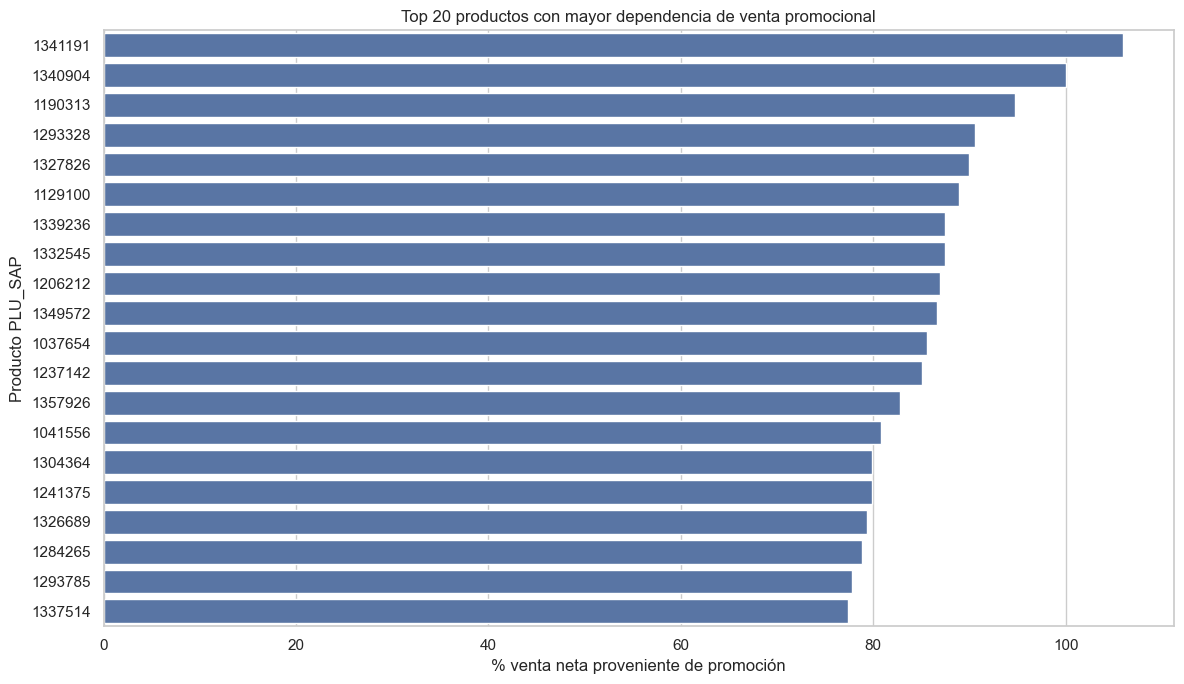

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\top_productos_dependencia_promo.png


In [31]:
# ===============================
# Top productos con mayor dependencia promocional
# ===============================

top_dependencia_promo = productos_dependencia_promo.head(20).copy()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_dependencia_promo,
    y="PLU_SAP",
    x="participacion_venta_promo_pct"
)

plt.title("Top 20 productos con mayor dependencia de venta promocional")
plt.xlabel("% venta neta proveniente de promoción")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "top_productos_dependencia_promo.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [32]:
# ===============================
# Productos con mayor descuento acumulado
# ===============================

top_productos_descuento = (
    productos_promo
    .sort_values("descuento", ascending=False)
    .head(20)
    .copy()
)

top_productos_descuento

,PLU_SAP,filas,lineas_promo,dias,pdv,categoria_principal,venta_bruta,descuento,venta_neta,unidades,tickets,promo_pct_lineas,descuento_pct,venta_neta_promo,venta_neta_sin_promo,participacion_venta_promo_pct
1516,1036253,2824,601,633,3,04010,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",2682,21.28,27.46,"278,219.00","929,797.00",23.03
3821,1289541,731,580,330,3,04010,"423,821.00","369,447.00","54,374.00",832.00,601,79.34,87.17,"-146,086.00","200,460.00",-268.67
3166,1246431,842,613,79,3,08029,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",627,72.80,21.23,"503,140.00","759,934.00",39.83
1518,1036266,4699,901,697,3,04010,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",4397,19.17,15.84,"234,479.00","1,393,399.00",14.40
3667,1281459,362,253,37,3,08029,"675,672.00","148,945.00","526,727.00",698.00,257,69.89,22.04,"208,966.00","317,761.00",39.67
1324,1023807,663,243,345,3,04010,"1,113,652.00","118,599.00","995,053.00",771.00,615,36.65,10.65,"212,835.00","782,218.00",21.39
5637,1366409,339,226,83,3,08029,"545,827.00","110,167.00","435,660.00",482.00,269,66.67,20.18,"111,926.00","323,734.00",25.69
1367,1025905,681,230,349,3,04010,"991,230.00","97,268.00","893,962.00",768.00,618,33.77,9.81,"153,347.00","740,615.00",17.15
5636,1366408,239,158,53,3,08029,"421,677.00","90,188.00","331,489.00",391.00,176,66.11,21.39,"60,663.00","270,826.00",18.30
1515,1036252,5075,925,708,3,04010,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",4735,18.23,6.79,"76,382.00","1,149,207.00",6.23


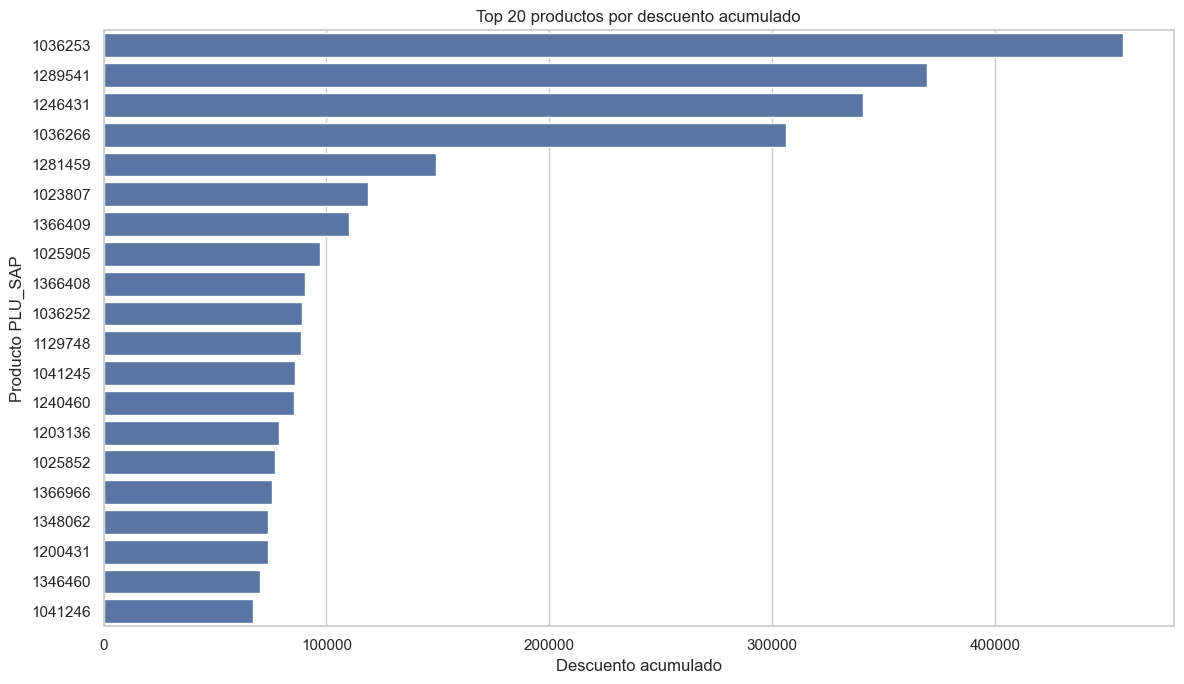

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\top_20_productos_descuento_acumulado.png


In [33]:
# ===============================
# Top productos por descuento acumulado
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_descuento,
    y="PLU_SAP",
    x="descuento"
)

plt.title("Top 20 productos por descuento acumulado")
plt.xlabel("Descuento acumulado")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "top_20_productos_descuento_acumulado.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [34]:
# ===============================
# Casos críticos de descuento
# ===============================

casos_criticos_descuento = pd.DataFrame({
    "caso": [
        "Descuento negativo",
        "Descuento igual a cero",
        "Descuento mayor que venta",
        "Descuento igual a venta",
        "Venta neta negativa",
        "Venta neta igual a cero",
        "Descuento porcentual mayor a 50%",
        "Descuento porcentual mayor a 100%"
    ],
    "cantidad": [
        (df["DESCUENTO"] < 0).sum(),
        (df["DESCUENTO"] == 0).sum(),
        (df["DESCUENTO"] > df["VENTA"]).sum(),
        (df["DESCUENTO"] == df["VENTA"]).sum(),
        (df["VENTA_NETA"] < 0).sum(),
        (df["VENTA_NETA"] == 0).sum(),
        (df["DESCUENTO_PCT"] > 50).sum(),
        (df["DESCUENTO_PCT"] > 100).sum()
    ]
})

casos_criticos_descuento["porcentaje"] = (
    casos_criticos_descuento["cantidad"] / len(df) * 100
)

casos_criticos_descuento

,caso,cantidad,porcentaje
0,Descuento negativo,12,0.00
1,Descuento igual a cero,300755,73.40
2,Descuento mayor que venta,8799,2.15
3,Descuento igual a venta,4521,1.10
4,Venta neta negativa,8799,2.15
5,Venta neta igual a cero,4521,1.10
6,Descuento porcentual mayor a 50%,21111,5.15
7,Descuento porcentual mayor a 100%,5813,1.42


In [35]:
# ===============================
# Muestra descuentos mayores que venta
# ===============================

cols_revision = [
    "NroReg",
    "FECHA",
    "PDV",
    "CATEG",
    "PLU_SAP",
    "OFERTA_ID",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PROMO_FLAG",
    "TIPO_PROMO",
    "REGISTRO_ESPECIAL"
]

descuento_mayor_venta = df[df["DESCUENTO"] > df["VENTA"]].copy()

print(f"Filas con descuento mayor que venta: {len(descuento_mayor_venta):,}")

descuento_mayor_venta[cols_revision].head(30)

Filas con descuento mayor que venta: 8,799


,NroReg,FECHA,PDV,CATEG,PLU_SAP,OFERTA_ID,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PROMO_FLAG,TIPO_PROMO,REGISTRO_ESPECIAL
366,8554,2023-01-02,1255,08042,1341191,163446,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento,True
586,14729,2023-01-02,980,08029,1115190,0,-1.00,-438.00,0.00,-438.00,NaN,False,Sin promoción,True
601,15053,2023-01-02,1255,08042,1341191,163446,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento,True
2041,53861,2023-01-05,980,04010,1334627,0,-1.00,-228.00,0.00,-228.00,NaN,False,Sin promoción,True
2181,57343,2023-01-06,980,04010,1153834,163364,1.00,249.00,374.00,-125.00,150.20,True,Oferta y descuento,True
2218,57837,2023-01-06,980,04010,1036252,163484,1.00,0.00,120.00,-120.00,NaN,True,Oferta y descuento,True
2220,57847,2023-01-06,980,04010,1129746,163364,1.00,204.00,307.00,-103.00,150.49,True,Oferta y descuento,True
2234,58044,2023-01-06,1311,04010,1249844,163364,1.00,219.00,329.00,-110.00,150.23,True,Oferta y descuento,True
2258,58631,2023-01-06,1255,04010,1023640,163364,1.00,179.00,269.00,-90.00,150.28,True,Oferta y descuento,True
2295,59480,2023-01-06,1255,08042,1341191,163446,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento,True


In [36]:
# ===============================
# Muestra ventas netas negativas
# ===============================

venta_neta_negativa = df[df["VENTA_NETA"] < 0].copy()

print(f"Filas con venta neta negativa: {len(venta_neta_negativa):,}")

venta_neta_negativa[cols_revision].head(30)

Filas con venta neta negativa: 8,799


,NroReg,FECHA,PDV,CATEG,PLU_SAP,OFERTA_ID,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PROMO_FLAG,TIPO_PROMO,REGISTRO_ESPECIAL
366,8554,2023-01-02,1255,08042,1341191,163446,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento,True
586,14729,2023-01-02,980,08029,1115190,0,-1.00,-438.00,0.00,-438.00,NaN,False,Sin promoción,True
601,15053,2023-01-02,1255,08042,1341191,163446,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento,True
2041,53861,2023-01-05,980,04010,1334627,0,-1.00,-228.00,0.00,-228.00,NaN,False,Sin promoción,True
2181,57343,2023-01-06,980,04010,1153834,163364,1.00,249.00,374.00,-125.00,150.20,True,Oferta y descuento,True
2218,57837,2023-01-06,980,04010,1036252,163484,1.00,0.00,120.00,-120.00,NaN,True,Oferta y descuento,True
2220,57847,2023-01-06,980,04010,1129746,163364,1.00,204.00,307.00,-103.00,150.49,True,Oferta y descuento,True
2234,58044,2023-01-06,1311,04010,1249844,163364,1.00,219.00,329.00,-110.00,150.23,True,Oferta y descuento,True
2258,58631,2023-01-06,1255,04010,1023640,163364,1.00,179.00,269.00,-90.00,150.28,True,Oferta y descuento,True
2295,59480,2023-01-06,1255,08042,1341191,163446,1.00,178.00,416.00,-238.00,233.71,True,Oferta y descuento,True


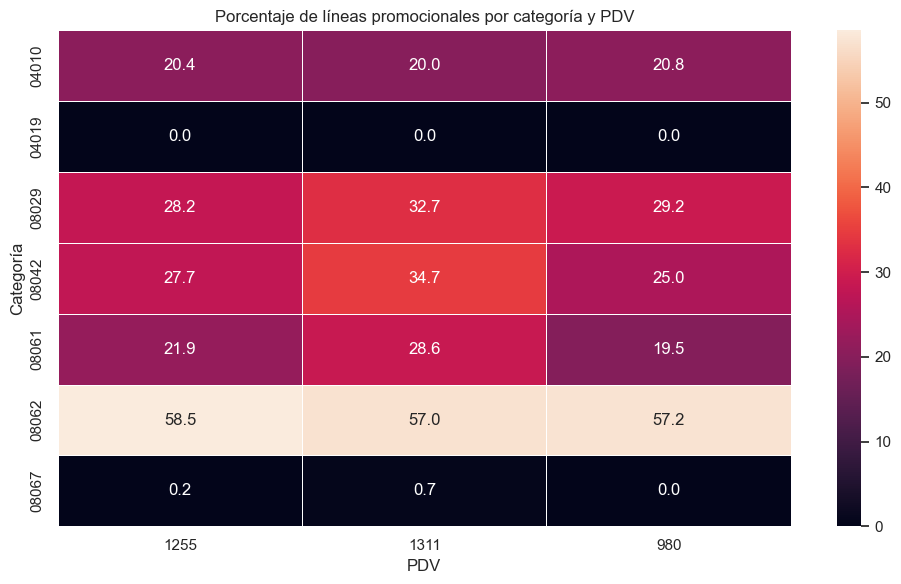

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\heatmap_promo_categoria_pdv.png


In [37]:
# ===============================
# Heatmap de promoción por categoría y PDV
# ===============================

promo_categoria_pdv = (
    df.groupby(["CATEG", "PDV"])
    .agg(
        filas=("NroReg", "count"),
        lineas_promo=("PROMO_FLAG", "sum"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum")
    )
    .reset_index()
)

promo_categoria_pdv["promo_pct_lineas"] = np.where(
    promo_categoria_pdv["filas"] > 0,
    promo_categoria_pdv["lineas_promo"] / promo_categoria_pdv["filas"] * 100,
    np.nan
)

tabla_heatmap_promo = promo_categoria_pdv.pivot_table(
    index="CATEG",
    columns="PDV",
    values="promo_pct_lineas",
    fill_value=0
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_heatmap_promo,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Porcentaje de líneas promocionales por categoría y PDV")
plt.xlabel("PDV")
plt.ylabel("Categoría")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "heatmap_promo_categoria_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

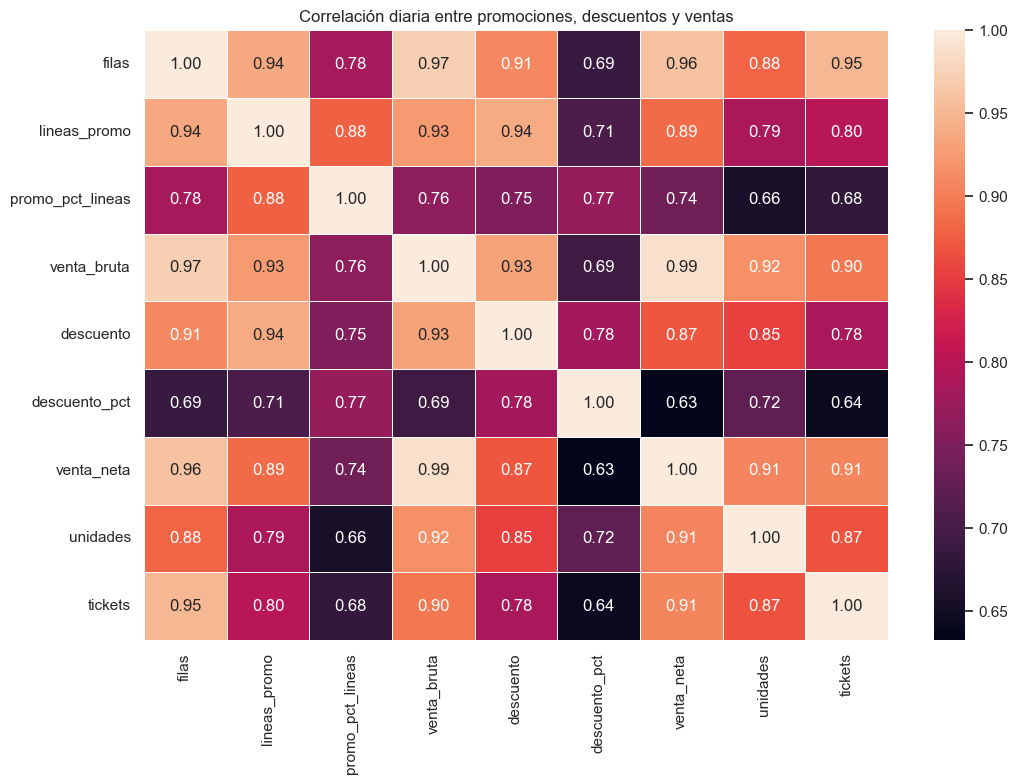

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\promociones\correlacion_promo_descuento_venta_diaria.png


In [38]:
# ===============================
# Correlación de métricas diarias de promoción
# ===============================

cols_corr_promo = [
    "filas",
    "lineas_promo",
    "promo_pct_lineas",
    "venta_bruta",
    "descuento",
    "descuento_pct",
    "venta_neta",
    "unidades",
    "tickets"
]

corr_promo_diaria = promo_diaria[cols_corr_promo].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_promo_diaria,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlación diaria entre promociones, descuentos y ventas")
plt.tight_layout()

output_fig = PROMOCIONES_FIGURES_DIR / "correlacion_promo_descuento_venta_diaria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [39]:
# ===============================
# Resumen ejecutivo de promociones
# ===============================

resumen_ejecutivo_promociones = pd.DataFrame({
    "metrica": [
        "Filas totales",
        "Filas con promoción",
        "% filas con promoción",
        "Venta neta total",
        "Venta neta promocional",
        "% venta neta promocional",
        "Descuento total",
        "Descuento / venta bruta (%)",
        "PDV con mayor % líneas promocionales",
        "Mayor % líneas promocionales por PDV",
        "Categoría con mayor % líneas promocionales",
        "Mayor % líneas promocionales por categoría",
        "Producto con mayor venta promocional",
        "Mayor venta promocional de producto",
        "Filas con descuento mayor que venta",
        "Filas con venta neta negativa"
    ],
    "valor": [
        len(df),
        df["PROMO_FLAG"].sum(),
        df["PROMO_FLAG"].mean() * 100,
        df["VENTA_NETA"].sum(),
        df.loc[df["PROMO_FLAG"], "VENTA_NETA"].sum(),
        df.loc[df["PROMO_FLAG"], "VENTA_NETA"].sum() / df["VENTA_NETA"].sum() * 100,
        df["DESCUENTO"].sum(),
        df["DESCUENTO"].sum() / df["VENTA"].sum() * 100,
        promo_pdv.sort_values("promo_pct_lineas", ascending=False).iloc[0]["PDV"],
        promo_pdv.sort_values("promo_pct_lineas", ascending=False).iloc[0]["promo_pct_lineas"],
        promo_categoria.sort_values("promo_pct_lineas", ascending=False).iloc[0]["CATEG"],
        promo_categoria.sort_values("promo_pct_lineas", ascending=False).iloc[0]["promo_pct_lineas"],
        top_productos_venta_promo.iloc[0]["PLU_SAP"],
        top_productos_venta_promo.iloc[0]["venta_neta_promo"],
        (df["DESCUENTO"] > df["VENTA"]).sum(),
        (df["VENTA_NETA"] < 0).sum()
    ]
})

resumen_ejecutivo_promociones

,metrica,valor
0,Filas totales,409760
1,Filas con promoción,109239
2,% filas con promoción,26.66
3,Venta neta total,"123,192,362.00"
4,Venta neta promocional,"25,002,304.00"
5,% venta neta promocional,20.30
6,Descuento total,"16,270,136.00"
7,Descuento / venta bruta (%),11.67
8,PDV con mayor % líneas promocionales,1311
9,Mayor % líneas promocionales por PDV,28.74


In [40]:
# ===============================
# Exportar tablas del análisis de promociones
# ===============================

output_excel = TABLES_DIR / "06_analisis_promociones_descuentos.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_promociones_general.to_excel(writer, sheet_name="resumen_general", index=False)
    resumen_promo_flag.to_excel(writer, sheet_name="promo_vs_no_promo", index=False)
    resumen_tipo_promo.to_excel(writer, sheet_name="tipo_promo", index=False)
    estadisticos_descuento.to_excel(writer, sheet_name="estadisticos_descuento", index=True)
    promo_pdv.to_excel(writer, sheet_name="promo_pdv", index=False)
    promo_categoria.to_excel(writer, sheet_name="promo_categoria", index=False)
    promo_diaria.to_excel(writer, sheet_name="promo_diaria", index=False)
    promo_mensual.to_excel(writer, sheet_name="promo_mensual", index=False)
    productos_promo.to_excel(writer, sheet_name="productos_promo", index=False)
    top_productos_venta_promo.to_excel(writer, sheet_name="top_venta_promo", index=False)
    productos_dependencia_promo.to_excel(writer, sheet_name="dependencia_promo", index=False)
    top_productos_descuento.to_excel(writer, sheet_name="top_descuento", index=False)
    casos_criticos_descuento.to_excel(writer, sheet_name="casos_criticos", index=False)
    descuento_mayor_venta[cols_revision].to_excel(writer, sheet_name="descuento_mayor_venta", index=False)
    venta_neta_negativa[cols_revision].to_excel(writer, sheet_name="venta_neta_negativa", index=False)
    promo_categoria_pdv.to_excel(writer, sheet_name="promo_categoria_pdv", index=False)
    corr_promo_diaria.to_excel(writer, sheet_name="corr_promo_diaria", index=True)
    resumen_ejecutivo_promociones.to_excel(writer, sheet_name="resumen_ejecutivo", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\06_analisis_promociones_descuentos.xlsx


## Conclusiones del análisis de promociones y descuentos

A partir del análisis de promociones y descuentos, se identifican varios puntos relevantes:

1. Las promociones representan una parte importante de la operación comercial, por lo que no deben tratarse como una variable secundaria.

2. La comparación entre líneas con promoción y sin promoción permite observar diferencias en venta neta, unidades, tickets y descuentos.

3. El porcentaje de líneas promocionales varía entre PDV, lo cual indica que no todas las tiendas tienen la misma intensidad promocional.

4. Las categorías también presentan comportamientos promocionales diferentes. Algunas categorías dependen más de descuentos u ofertas que otras.

5. El análisis temporal muestra que la intensidad promocional cambia a lo largo del tiempo. Esto puede ayudar a explicar picos o caídas de venta neta.

6. El análisis por producto permite identificar SKUs con alta dependencia promocional, es decir, productos cuya venta neta proviene mayoritariamente de líneas promocionales.

7. Los productos con mayor descuento acumulado deben revisarse porque pueden tener impacto importante sobre el margen o sobre la venta neta.

8. Los casos donde el descuento supera la venta generan venta neta negativa. Estos registros no deben eliminarse automáticamente, pero sí deben analizarse como devoluciones, ajustes, errores operativos o promociones especiales.

9. Para un futuro modelo predictivo, las variables promocionales deben considerarse cuidadosamente. Algunas variables útiles serían:

   - `PROMO_FLAG`
   - `TIPO_PROMO`
   - `DESCUENTO`
   - `DESCUENTO_PCT`
   - porcentaje de líneas promocionales por día
   - porcentaje de líneas promocionales por producto
   - dependencia promocional del producto
   - intensidad promocional por PDV y categoría

10. Las promociones pueden tener una relación importante con la venta, pero el EDA por sí solo no demuestra causalidad. Para medir impacto real sería necesario comparar periodos similares con y sin promoción, o aplicar diseños analíticos más controlados.